# Using the `ask`-and-`tell` Interface

As a first example, we optimize the 5D ellipsoid function.

In [1]:
import cma

fun = cma.ff.elli  # see basics notebook
es = cma.CMAEvolutionStrategy(5 * [1], 1)  # x0, sigma0
while not es.stop():
    X = es.ask()  # sample candidate solutions
    f_values = [fun(x) for x in X]  # a relative ranking of solutions suffices
    es.tell(X, f_values)  # update state variables
    es.logger.add()  # preserve data for plotting
    es.disp()
es.result_pretty()

(4_w,8)-aCMA-ES (mu_w=2.6,w_1=52%) in dimension 5 (seed=584687, Thu Dec 11 21:27:31 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 3.008430199971560e+03 1.0e+00 1.00e+00  9e-01  1e+00 0:00.0
    2     16 8.868669203119817e+04 1.4e+00 8.74e-01  8e-01  9e-01 0:00.0
    3     24 8.291840472201019e+04 1.3e+00 9.06e-01  7e-01  1e+00 0:00.0
  100    800 8.006976739563372e+00 3.5e+02 1.73e-01  1e-03  4e-01 0:00.0
  200   1600 1.495539370482126e-09 1.0e+03 8.38e-05  3e-08  3e-05 0:00.1
  247   1976 1.169775749549975e-14 1.6e+03 7.15e-07  5e-11  7e-08 0:00.1
termination on {'tolfun': 1e-11}
final/bestever f-value = 1.169776e-14 4.408864e-15 after 1976/1959 evaluations
incumbent solution: [-2.09789392e-08, 1.26202125e-08, -1.22234573e-09, -3.64060738e-10, -6.59415186e-12]
std deviations: [6.93738528e-08, 9.18088414e-09, 1.46431584e-09, 3.78645945e-10, 4.74227163e-11]


CMAEvolutionStrategyResult2(xbest=array([ 1.73202897e-08, -3.14767190e-09, -9.01118765e-10, -4.57029000e-11,
        5.40138053e-11]), fbest=4.408864222764053e-15, evals_best=1959, best_feasible={'x': array([ 1.73202897e-08, -3.14767190e-09, -9.01118765e-10, -4.57029000e-11,
        5.40138053e-11]), 'f': 4.408864222764053e-15, 'g': None, 'evals': 1959, 'feasible_iterations': None}, evaluations=1976, iterations=247, xfavorite=array([-2.09789392e-08,  1.26202125e-08, -1.22234573e-09, -3.64060738e-10,
       -6.59415186e-12]), stds=array([6.93738528e-08, 9.18088414e-09, 1.46431584e-09, 3.78645945e-10,
       4.74227163e-11]), stop={'tolfun': 1e-11})

Only the termination detection uses function values. The respective conditions

In [2]:
cma.CMAOptions('tol')

{'mindx': '0  #v minimal std in any arbitrary direction, cave interference with tol*',
 'minstd': '0  #v minimal std (scalar or vector) in any coordinate direction, cave interference with tol*',
 'tolconditioncov': '1e14  #v stop if the condition of the covariance matrix is above `tolconditioncov`',
 'tolfacupx': '1e3  #v termination when step-size increases by tolfacupx (diverges). That is, the initial step-size was chosen far too small and better solutions were found far away from the initial solution x0',
 'tolflatfitness': '1  #v iterations tolerated with flat fitness before termination',
 'tolfun': '1e-11  #v termination criterion: tolerance in function value, quite useful',
 'tolfunhist': '1e-12  #v termination criterion: tolerance in function value history',
 'tolfunrel': '0  #v termination criterion: relative tolerance in function value: Delta f current < tolfunrel * (median0 - median_min)',
 'tolstagnation': 'int(100 + 100 * N**1.5 / popsize)  #v termination if no improvement 

can be turned off, for example by passing the option ``{'tolfun': 0}`` as below.

The ``es.logger.add()`` line under the above `while` loop writes data that can be plotted.

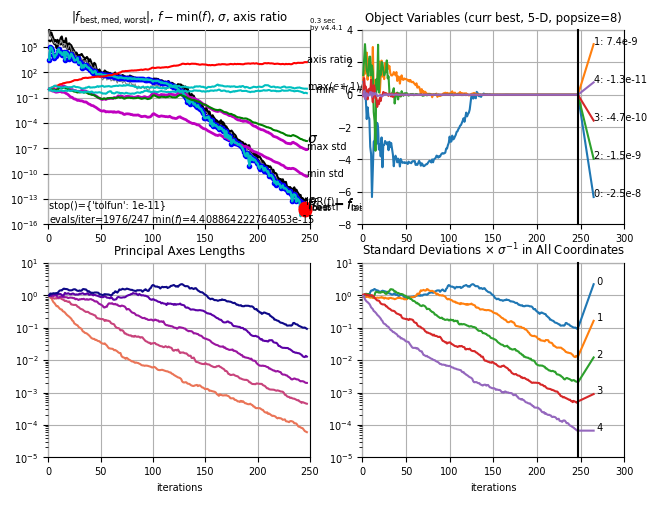

In [3]:
# %matplotlib widget
p = es.plot()

The above iterations can be equally done like

In [4]:
es = cma.CMAEvolutionStrategy(5 * [1], 1, {'tolfun': 0})  # x0, sigma0
while not es.stop():
    es.optimize(fun, iterations=1)

(4_w,8)-aCMA-ES (mu_w=2.6,w_1=52%) in dimension 5 (seed=564741, Thu Dec 11 21:27:32 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 1.198627337961540e+04 1.0e+00 1.05e+00  1e+00  1e+00 0:00.0
    2     16 1.376130999667573e+05 1.3e+00 1.09e+00  1e+00  1e+00 0:00.0
    3     24 2.341633194552827e+04 1.5e+00 1.17e+00  1e+00  1e+00 0:00.0
  100    800 4.459912198777035e-02 8.7e+02 2.76e-02  1e-04  1e-01 0:00.0
  200   1600 3.417209650424084e-12 9.4e+02 4.02e-06  1e-09  1e-06 0:00.1
  232   1856 9.306679225685413e-16 1.0e+03 1.55e-07  2e-11  2e-08 0:00.1
termination on {'tolfunhist': 1e-12}
final/bestever f-value = 9.306679e-16 7.365525e-16 after 1856/1842 evaluations
incumbent solution: [ 1.99195565e-08, -1.92237785e-10, 4.06976357e-10, 8.95277292e-12, 4.79456627e-12]
std deviations: [1.57293618e-08, 3.00440386e-09, 4.77653300e-10, 7.16848157e-11, 1.58914548e-11]


and with a single call of `es.optimize` when the `iterations` argument is omitted.

(4_w,8)-aCMA-ES (mu_w=2.6,w_1=52%) in dimension 5 (seed=627144, Thu Dec 11 21:27:32 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 1.061159659068594e+05 1.0e+00 9.18e-01  9e-01  9e-01 0:00.0
    2     16 1.200501705516574e+04 1.2e+00 8.24e-01  7e-01  8e-01 0:00.0
    3     24 2.785425658733028e+04 1.3e+00 8.31e-01  7e-01  8e-01 0:00.0
  100    800 2.550248959949580e-02 5.6e+02 3.53e-02  2e-04  9e-02 0:00.0
  200   1600 2.009700889026304e-14 1.2e+03 6.09e-07  1e-10  1e-07 0:00.1
  203   1624 1.408545805243023e-14 1.2e+03 4.56e-07  7e-11  8e-08 0:00.1
termination on {'tolfun': 1e-11}
final/bestever f-value = 1.408546e-14 4.890430e-15 after 1624/1602 evaluations
incumbent solution: [-5.56363364e-08, -3.85618635e-09, 1.20579872e-09, -3.52451375e-10, -3.91225687e-11]
std deviations: [8.24251329e-08, 1.33466327e-08, 2.77579244e-09, 4.15373508e-10, 7.31710203e-11]


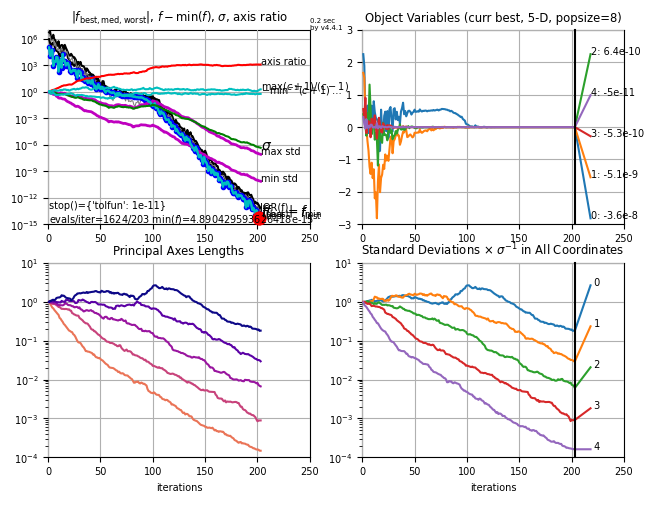

In [5]:
es = cma.CMAEvolutionStrategy(5 * [1], 1)  # x0, sigma0
es.optimize(fun)
es.plot();